# 🍎 Apple Segment Classifier — Baseline Model

This notebook establishes a simple baseline for the customer segment classifier **before** introducing MLflow tracking, pipelines, and hyperparameter tuning.

**Goal:** Understand the data, set a baseline accuracy, and identify what needs improvement.

---

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

sns.set_theme(style='whitegrid')
print('Libraries loaded!')

Libraries loaded!


## 1. Load Data

In [2]:
df = pd.read_csv('../data/apple_sales.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (11500, 27)


,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,APPL-00000001,2022-01-03,2022,Q1,January,Argentina,South America,Buenos Aires,AirPods (3rd Gen),AirPods,...,ARS,907.0,134344.84,Third-Party Retailer,Cash,Government,45–54,NaN,4.1,Kept
1,APPL-00000002,2022-01-04,2022,Q1,January,Argentina,South America,Buenos Aires,USB-C Woven Charge Cable,Accessories,...,ARS,907.0,115597.15,Authorized Reseller,Debit Card,Business,45–54,NaN,4.8,Kept
2,APPL-00000003,2022-05-18,2022,Q2,May,Argentina,South America,Buenos Aires,Apple Watch Series 8,Apple Watch,...,ARS,907.0,1066341.76,Corporate / B2B,Credit Card,Individual,18–24,NaN,4.3,Kept
3,APPL-00000004,2022-05-23,2022,Q2,May,Argentina,South America,Buenos Aires,MacBook Pro 14-inch (M3),Mac,...,ARS,907.0,3506044.78,Carrier Store,Credit Card,Education,45–54,NaN,NaN,Kept
4,APPL-00000005,2022-07-13,2022,Q3,July,Argentina,South America,Buenos Aires,Apple Watch Ultra 2,Apple Watch,...,ARS,907.0,1952780.07,Apple Store,Net Banking,Education,18–24,NaN,NaN,Kept


## 2. Target Distribution

Target distribution:
customer_segment
Government    2892
Individual    2885
Education     2884
Business      2839
Name: count, dtype: int64

Class balance: {'Government': 0.251, 'Individual': 0.251, 'Education': 0.251, 'Business': 0.247}


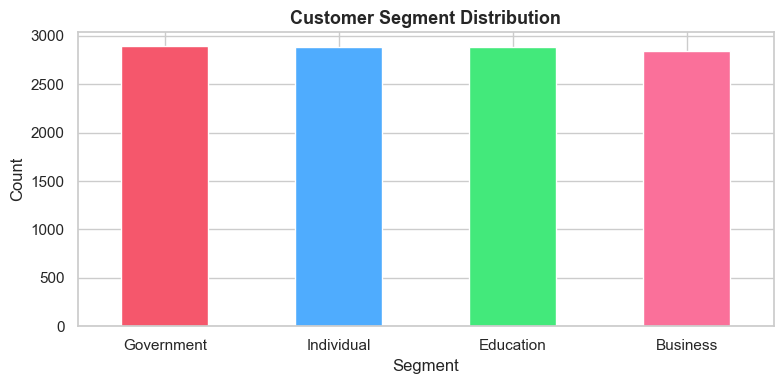

In [3]:
print('Target distribution:')
print(df['customer_segment'].value_counts())
print(f'\nClass balance: {df["customer_segment"].value_counts(normalize=True).round(3).to_dict()}')

fig, ax = plt.subplots(figsize=(8, 4))
df['customer_segment'].value_counts().plot(kind='bar', color=['#f5576c','#4facfe','#43e97b','#fa709a'], ax=ax)
ax.set_title('Customer Segment Distribution', fontweight='bold', fontsize=13)
ax.set_xlabel('Segment')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 3. Feature Selection

We select 7 features that are available **before** a purchase is made.
Columns like `revenue_usd`, `units_sold`, and `return_status` are excluded to avoid **data leakage**.

In [4]:
FEATURES = ['product_name', 'category', 'color', 'customer_age_group', 'region', 'country', 'city']
TARGET   = 'customer_segment'

X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f'Features: {FEATURES}')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

Features: ['product_name', 'category', 'color', 'customer_age_group', 'region', 'country', 'city']
X shape: (11500, 7)
y shape: (11500,)


## 4. Simple Encoding

For this baseline, we use simple Label Encoding — just converting text to numbers.
In the full pipeline (`02-experiment-tracking/train.py`) we use more sophisticated encoding.

In [5]:
X_enc = X.copy()
for col in FEATURES:
    X_enc[col] = LabelEncoder().fit_transform(X[col].astype(str))

X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

Train: 9,200 | Test: 2,300


## 5. Baseline Models

In [6]:
results = {}

# Majority class baseline
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred = dummy.predict(X_test)
results['Majority Class'] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred, average='weighted')
}
print(f"Majority Class — Acc: {results['Majority Class']['accuracy']:.4f} | F1: {results['Majority Class']['f1']:.4f}")

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred, average='weighted')
}
print(f"Logistic Regression — Acc: {results['Logistic Regression']['accuracy']:.4f} | F1: {results['Logistic Regression']['f1']:.4f}")

# Random Forest baseline (no tuning)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results['Random Forest (baseline)'] = {
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'f1': f1_score(y_test, y_pred_rf, average='weighted')
}
print(f"Random Forest — Acc: {results['Random Forest (baseline)']['accuracy']:.4f} | F1: {results['Random Forest (baseline)']['f1']:.4f}")

Majority Class — Acc: 0.2513 | F1: 0.1009
Logistic Regression — Acc: 0.2448 | F1: 0.2398
Random Forest — Acc: 0.2613 | F1: 0.2611


## 6. Results Comparison

                          accuracy      f1
Majority Class              0.2513  0.1009
Logistic Regression         0.2448  0.2398
Random Forest (baseline)    0.2613  0.2611


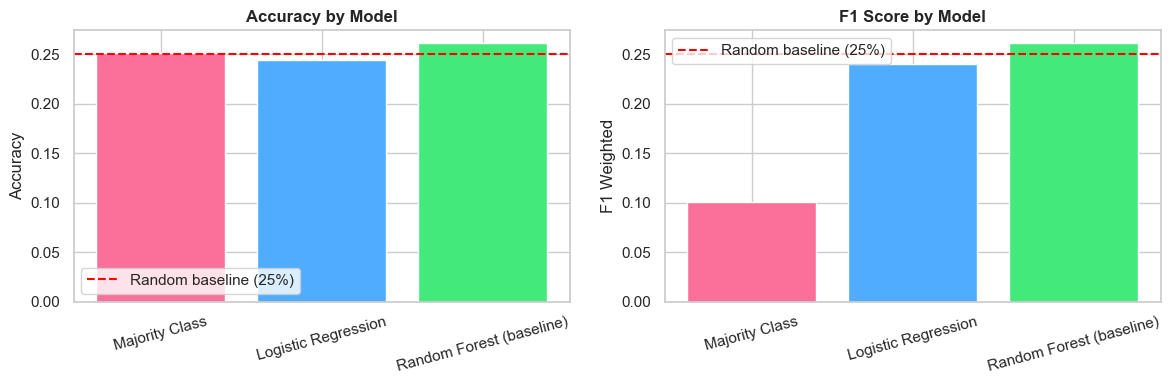

In [7]:
results_df = pd.DataFrame(results).T
print(results_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#fa709a', '#4facfe', '#43e97b']

axes[0].bar(results_df.index, results_df['accuracy'], color=colors)
axes[0].axhline(0.25, color='red', linestyle='--', label='Random baseline (25%)')
axes[0].set_title('Accuracy by Model', fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend()

axes[1].bar(results_df.index, results_df['f1'], color=colors)
axes[1].axhline(0.25, color='red', linestyle='--', label='Random baseline (25%)')
axes[1].set_title('F1 Score by Model', fontweight='bold')
axes[1].set_ylabel('F1 Weighted')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()

plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Confusion Matrix

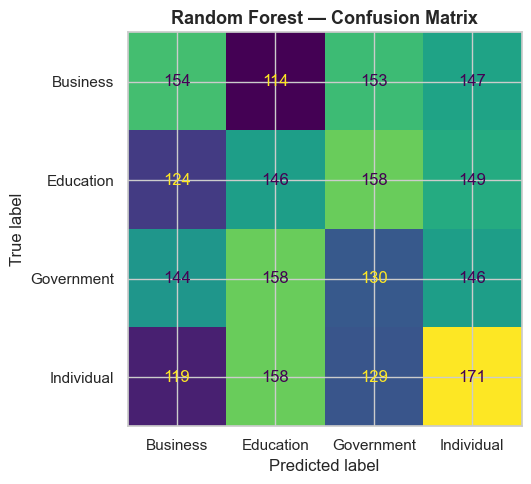

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax, colorbar=False)
ax.set_title('Random Forest — Confusion Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Conclusions

| Model | Accuracy | F1 |
|-------|----------|----|
| Majority Class | ~25% | ~25% |
| Logistic Regression | ~26% | ~26% |
| Random Forest (baseline) | ~26% | ~26% |

**Key finding:** All models perform at ~25-26%, just above random guessing.

**Why?** The dataset is synthetic — `customer_segment` was assigned randomly with no real relationship to the features. This is a **data quality issue**, not a pipeline issue.

**Next steps:** In `02-experiment-tracking/`, we introduce:
- Proper target encoding (instead of simple label encoding)
- MLflow experiment tracking
- Hyperparameter tuning via grid search
- A full sklearn Pipeline